# Learning Objectives
- Evaluate performance of the selected model.
- Use k-fold cross validation to compare the performance of a pair of models.
-  Use repeated k-fold cross validation to compare the performance of a pair of models.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv('Secom.csv', low_memory=False)
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 591 entries, Sensor 1 to Target
dtypes: float64(122), int64(1), object(468)
memory usage: 7.1+ MB
None


,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,Sensor 10,...,Sensor 582,Sensor 583,Sensor 584,Sensor 585,Sensor 586,Sensor 587,Sensor 588,Sensor 589,Sensor 590,Target
0,3030.93,2564,2187.7333,1411.1265,1.3602,100,97.6133,0.1242,1.5005,0.0162,...,!,0.5005,0.0118,0.0035,2.363,!,!,!,!,1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.006,208.2045,1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,0
3,2988.72,2479.9,2199.0333,909.7926,1.3204,100,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.499,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,1
4,3032.24,2502.87,2233.3667,1326.52,1.5334,100,100.3967,0.1235,1.5031,-0.0031,...,!,0.48,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,1


Question 1.1: Detect and replace missing values in the data with np.nan . Hint: missing data is noted as !

In [2]:
for feature in data.columns.tolist()[:1]: print(data[feature].value_counts())

!          6
2968.78    2
2908.11    2
3053.48    2
3100.96    2
          ..
2960.22    1
2991.74    1
2792.24    1
2933.27    1
2944.92    1
Name: Sensor 1, Length: 1521, dtype: int64


In [3]:
data.isna().sum()

Sensor 1      0
Sensor 2      0
Sensor 3      0
Sensor 4      0
Sensor 5      0
             ..
Sensor 587    0
Sensor 588    0
Sensor 589    0
Sensor 590    0
Target        0
Length: 591, dtype: int64

In [4]:
data = data.replace(regex="\!$",value=np.NAN)

In [5]:
for feature in data.columns.tolist()[:1]: print(data[feature].value_counts())

2968.78    2
2973.53    2
2990.85    2
2946.86    2
3012.98    2
          ..
2960.22    1
2991.74    1
2792.24    1
2933.27    1
2944.92    1
Name: Sensor 1, Length: 1520, dtype: int64


Question 1.2 Confirm that the change has worked

In [6]:
data.head()

,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,Sensor 10,...,Sensor 582,Sensor 583,Sensor 584,Sensor 585,Sensor 586,Sensor 587,Sensor 588,Sensor 589,Sensor 590,Target
0,3030.93,2564,2187.7333,1411.1265,1.3602,100,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.363,NaN,NaN,NaN,NaN,1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.006,208.2045,1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,0
3,2988.72,2479.9,2199.0333,909.7926,1.3204,100,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.499,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,1
4,3032.24,2502.87,2233.3667,1326.52,1.5334,100,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.48,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,1


Question 1.3: Fill the missing values with zeroes

In [7]:
data.isna().sum()

Sensor 1       6
Sensor 2       7
Sensor 3      14
Sensor 4      14
Sensor 5      14
              ..
Sensor 587     1
Sensor 588     1
Sensor 589     1
Sensor 590     1
Target         0
Length: 591, dtype: int64

In [8]:
data = data.replace(to_replace=np.NAN,value=0.0)

In [9]:
#Validate that the missing values were replaced
for feature in data.columns.tolist()[:1]: print(data[feature].value_counts())

0.0        6
2968.78    2
2908.11    2
3053.48    2
3100.96    2
          ..
2960.22    1
2991.74    1
2792.24    1
2933.27    1
2944.92    1
Name: Sensor 1, Length: 1521, dtype: int64


In [10]:
data.isna().sum()

Sensor 1      0
Sensor 2      0
Sensor 3      0
Sensor 4      0
Sensor 5      0
             ..
Sensor 587    0
Sensor 588    0
Sensor 589    0
Sensor 590    0
Target        0
Length: 591, dtype: int64

Question 2.1: Split the data into Training and testing. Make your test size = 0.2 and your random_state = 42.

In [13]:
X,y = data.drop(columns="Target"), data["Target"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
bak = [X_train, X_test, y_train, y_test]

Question 2.2: Fit a logistic regression model on the training data. Predict the test data and plot the ROC curve

In [139]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42, max_iter=8000, solver="saga", tol=1e-2).fit(X_train, y_train)

In [140]:
y_pred = lr.predict(X_test)
y_true = y_test

Plot ROC Curve

AUC: 0.5


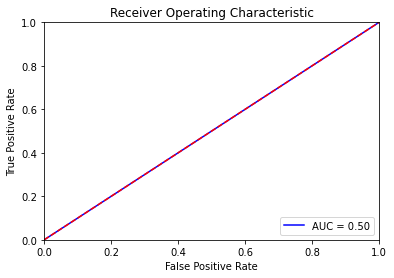

In [141]:
# Plot outputs
import matplotlib.pyplot as plt
import sklearn.metrics
from sklearn import preprocessing, metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

%matplotlib inline

# calculate the fpr and tpr for all thresholds of the classification

fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# Plot the ROC curve


plt.show()


print("AUC: {}".format(round(roc_auc,4)))

# Plot the ROC curve


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Question 2.2: Apply RFE with a logistic regression model on the training data testing out different number of features. Predict the test data and plot the ROC curve.

In [27]:
from sklearn.feature_selection import RFE
features = data.columns.tolist()

In [31]:
def rfe(n): return RFE(estimator=LogisticRegression(max_iter= 8000, random_state=42, solver="saga", warm_start=True, tol=1e-2), n_features_to_select=n) # I adjusted the tolerance to 1e-2 to make expedite the algo

In [136]:
models = [rfe(n+1).fit(X_train,y_train) for n in range(5)]

Plot ROC Curve

AUC: 0.5161


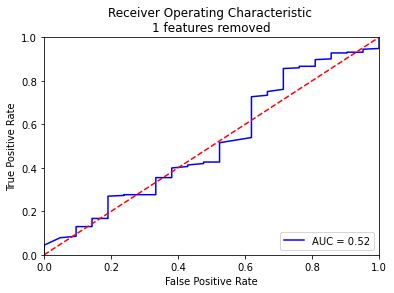

AUC: 0.4942


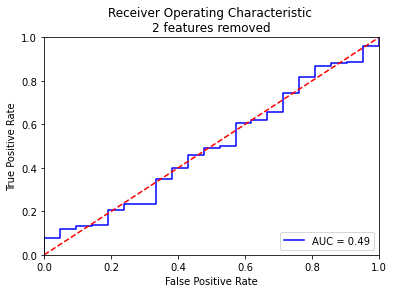

AUC: 0.4213


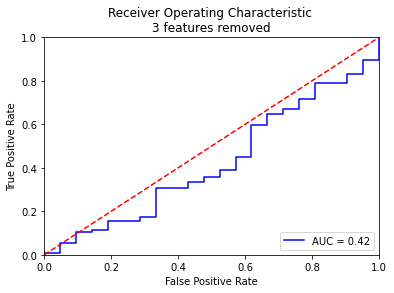

AUC: 0.4755


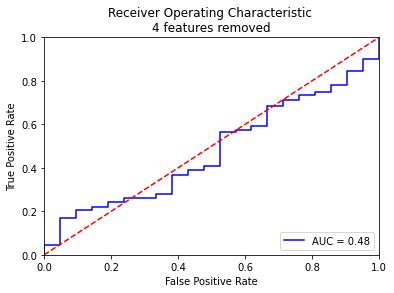

AUC: 0.4975


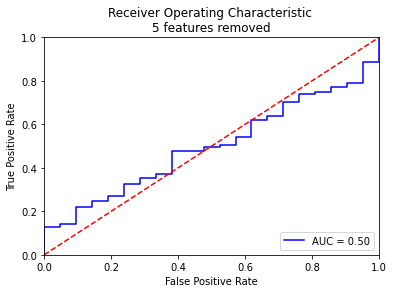

In [137]:
# Plot outputs
import matplotlib.pyplot as plt
import sklearn.metrics
from sklearn import preprocessing, metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

%matplotlib inline

names = [str(i+1)+" features removed" for i in range(5)]

for regr in models:
    # calculate the fpr and tpr for all thresholds of the classification
    probs = regr.predict_proba(X_test)
    preds = probs[:,1]
    fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
    roc_auc = metrics.auc(fpr, tpr)
    print("AUC: {}".format(round(roc_auc,4)))

    # Plot the ROC curve
    i = models.index(regr)
    name = names[i]
    
    plt.title('Receiver Operating Characteristic \n'+name)
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

Question 3.1: Apply stratisfied tain test split to account for class imbalance

In [132]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

Question 3.2: Apply RFE with a logistic regression model on the stratisfied training data testing out different number of features. Predict the test data and plot the ROC curve.

In [108]:
def rfe(n): return RFE(estimator=LogisticRegression(max_iter= 8000, random_state=42, solver="saga", warm_start=True, tol=1e-2), n_features_to_select=n, step=1)

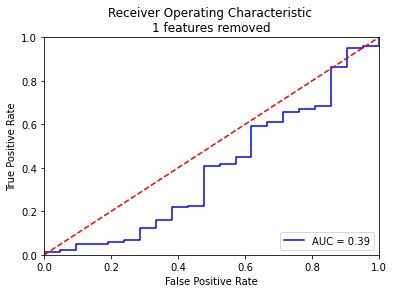

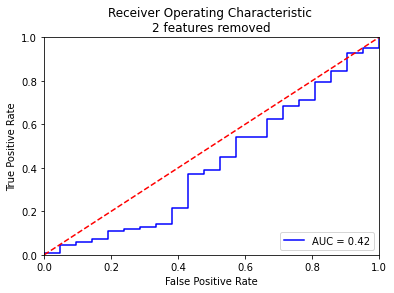

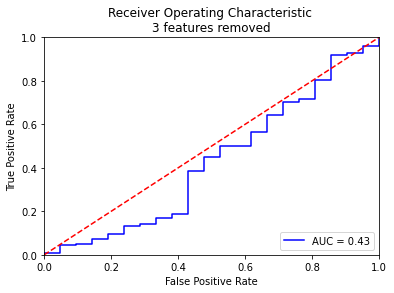

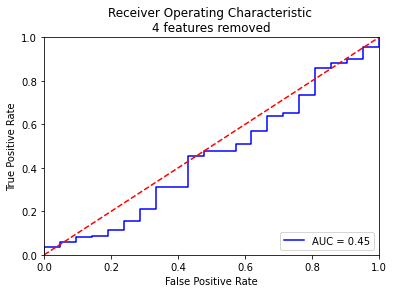

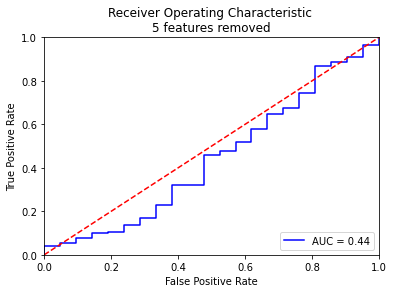

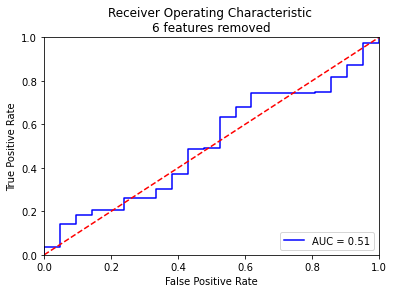

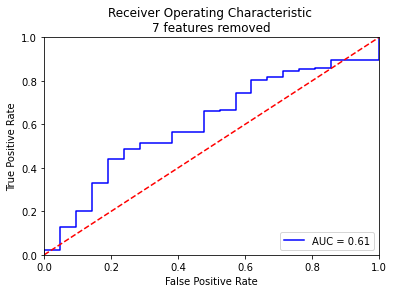

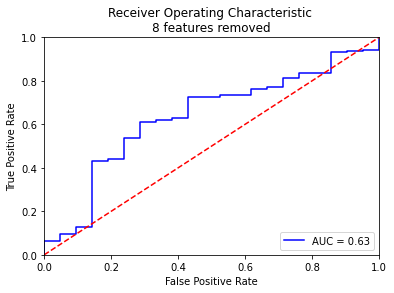

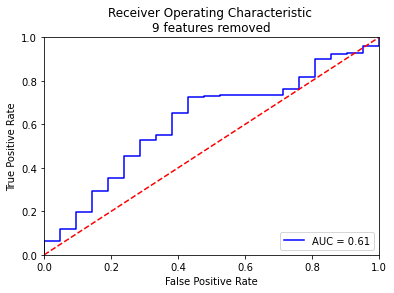

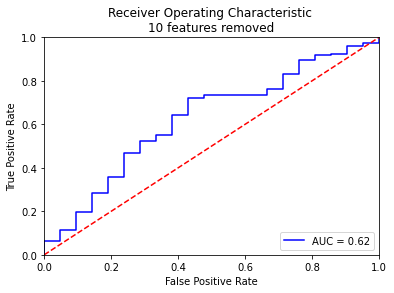

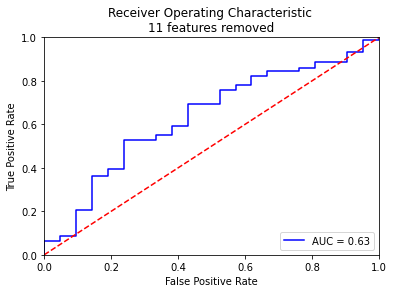

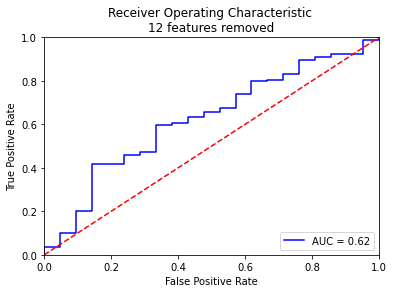

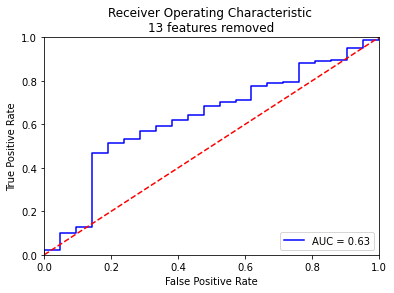

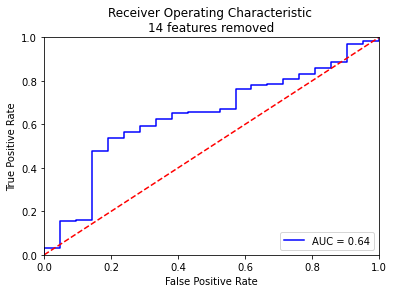

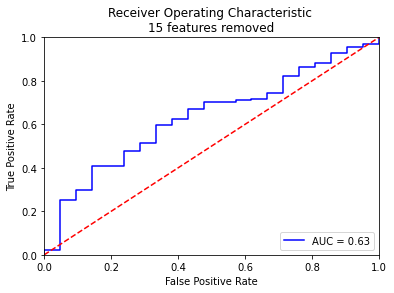

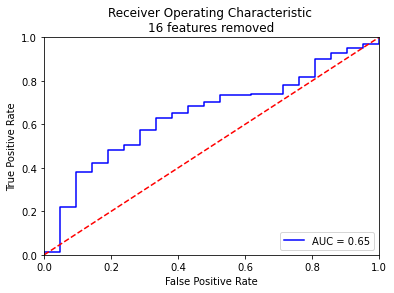

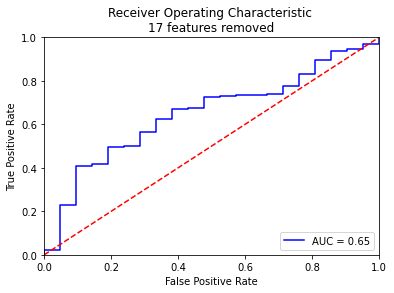

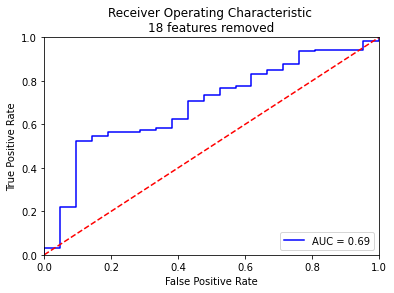

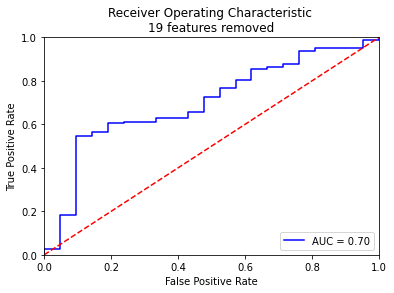

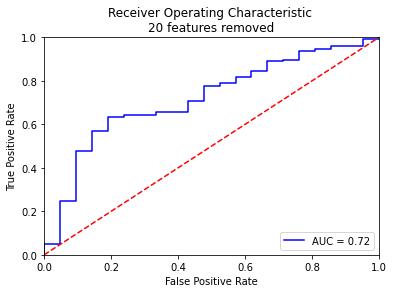

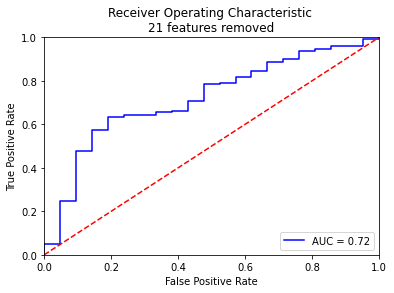

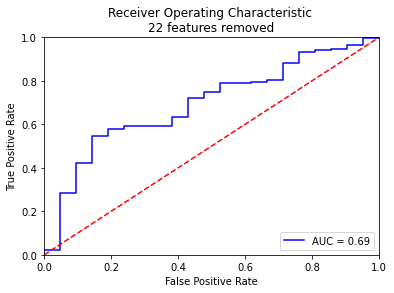

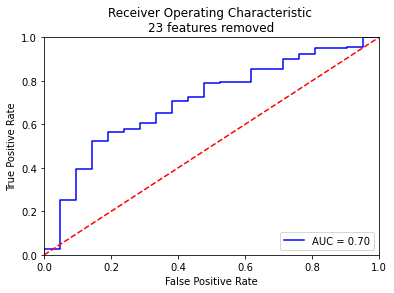

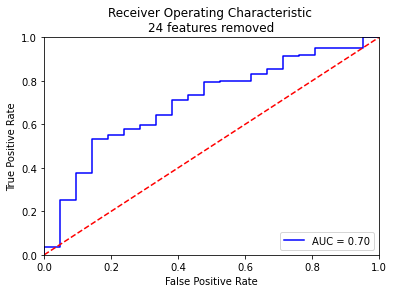

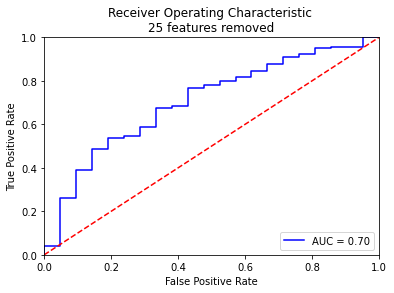

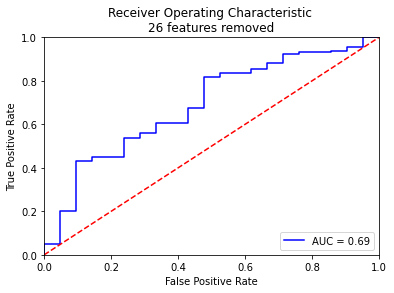

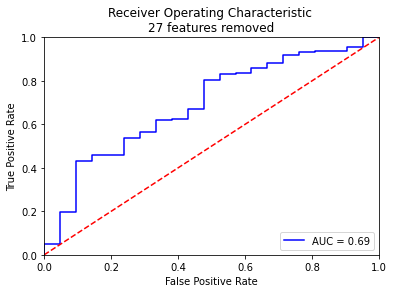

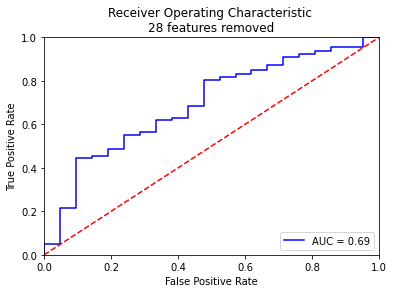

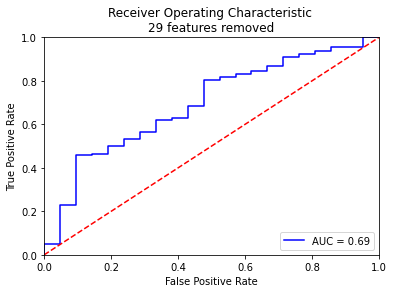

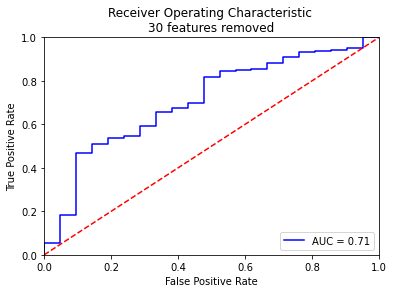

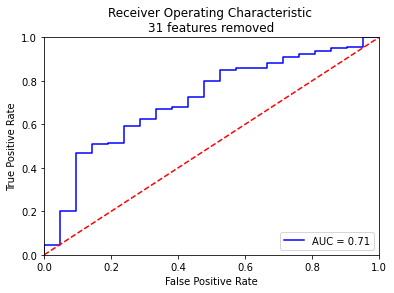

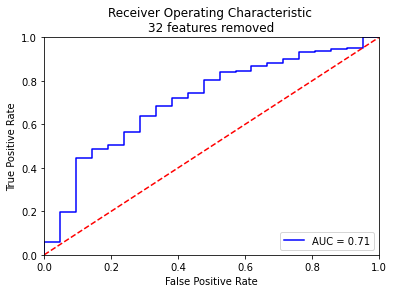

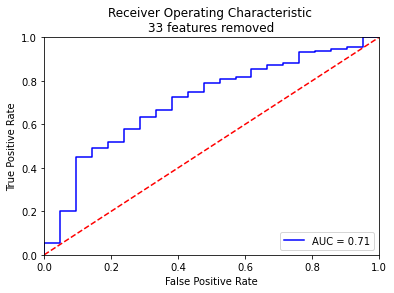

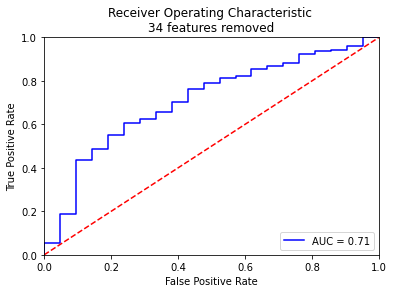

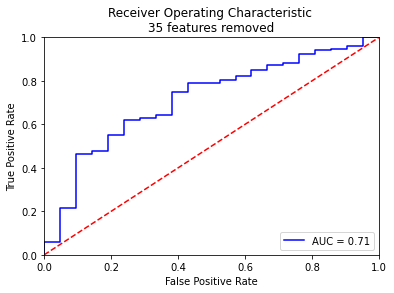

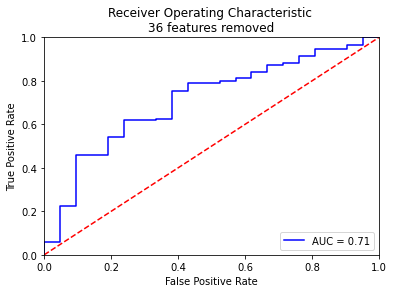

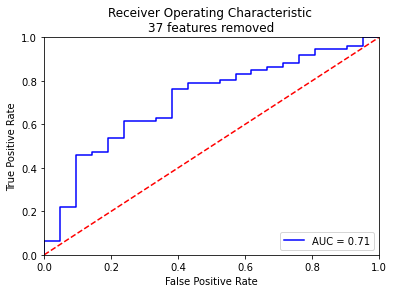

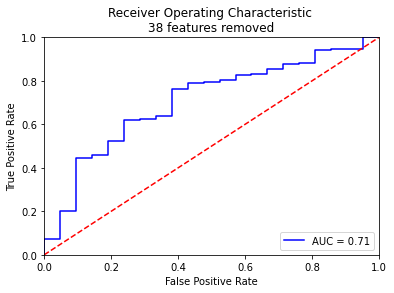

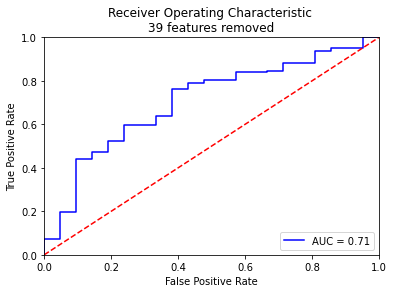

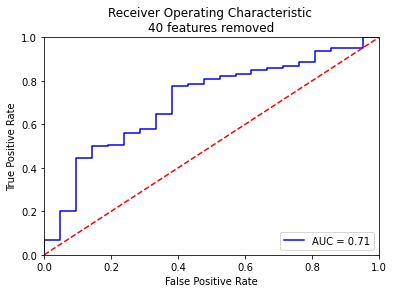

In [65]:
%matplotlib inline
models = []
y_preds = []
for i in range(40):
    model = rfe(i+1).fit(X_train,y_train)
    probs = model.predict_proba(X_test)
    preds = probs[:,1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, preds)
    roc_auc = metrics.auc(fpr, tpr)
    plt.title('Receiver Operating Characteristic \n'+str(i+1)+" features removed")
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

Question 4.1: Apply stratisfied K-Fold split where K=5 to the above data 

In [135]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5)

In [133]:
kX_trainindicies = []
kX_testindicies = []
for i, (train_index, test_index) in enumerate(skf.split(X,y)):
    kX_trainindicies.append(train_index)
    kX_testindicies.append(test_index)
kX_train = []
kX_test = []
for i in range(5):
    kX_train.append(X.iloc[kX_trainindicies[i]])
    kX_test.append(X.iloc[kX_testindicies[i]])

Implement the model and then create the ROC Curve

AUC: 0.5161


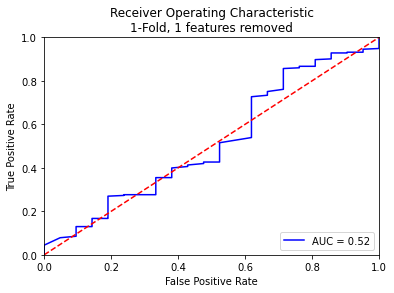

AUC: 0.4942


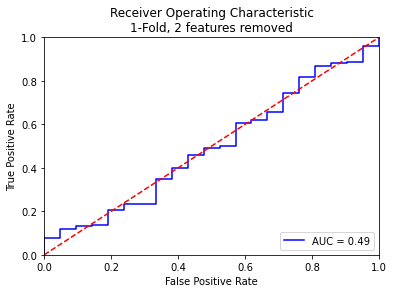

AUC: 0.4213


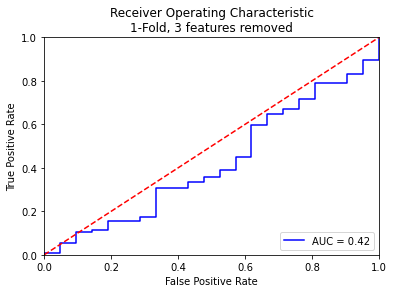

AUC: 0.4755


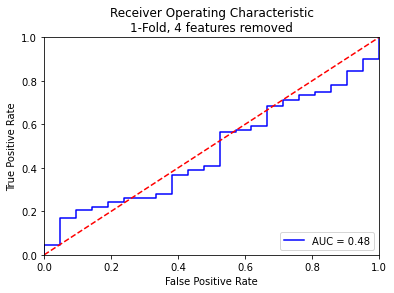

AUC: 0.3566


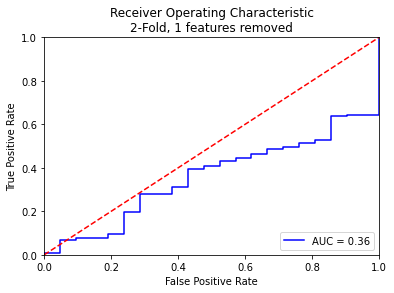

AUC: 0.41


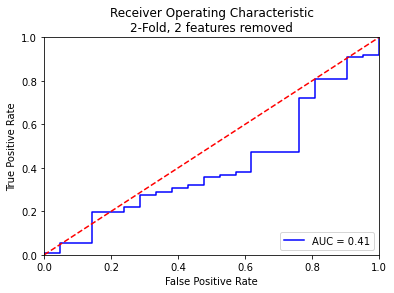

AUC: 0.4525


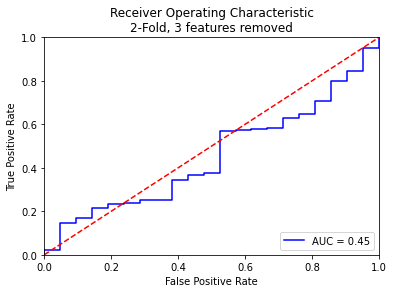

AUC: 0.5672


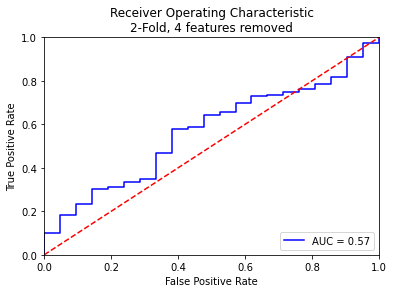

AUC: 0.3875


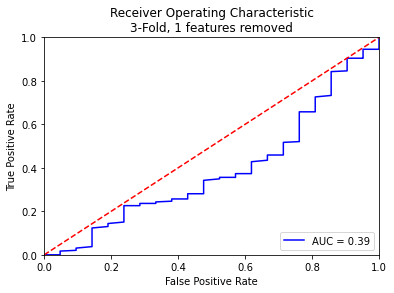

AUC: 0.462


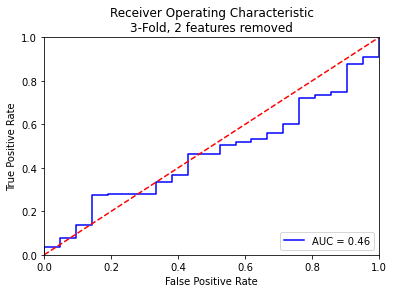

AUC: 0.5238


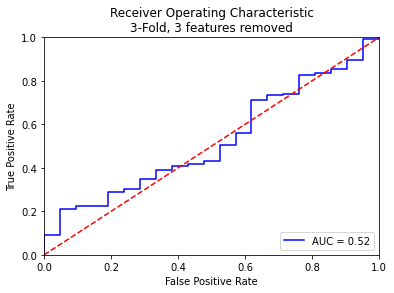

AUC: 0.5333


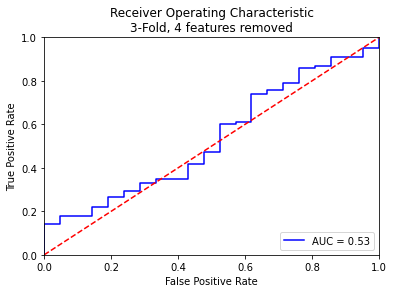

AUC: 0.4602


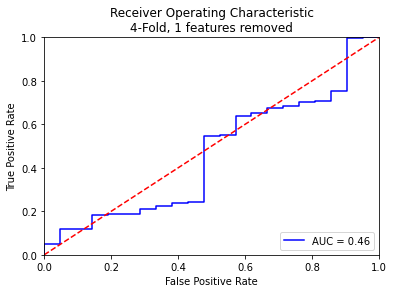

AUC: 0.4586


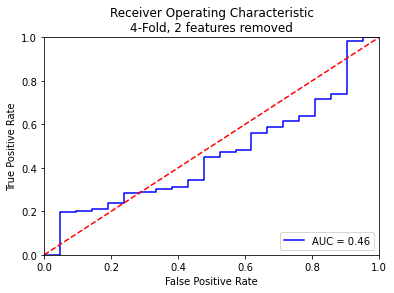

AUC: 0.4749


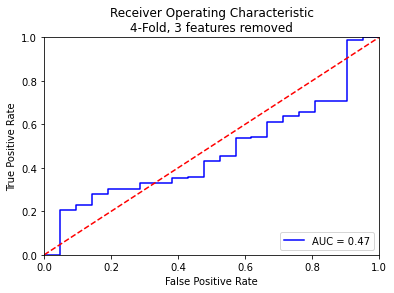

AUC: 0.4979


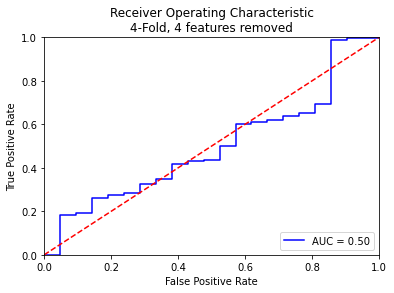

AUC: 0.6268


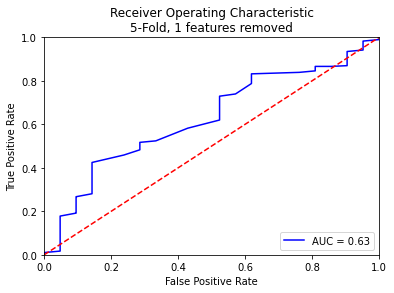

AUC: 0.5245


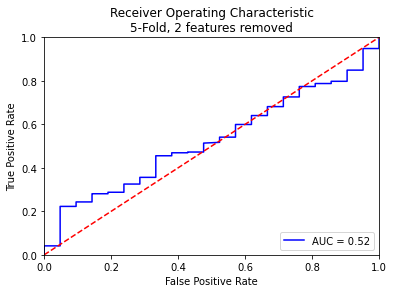

AUC: 0.5629


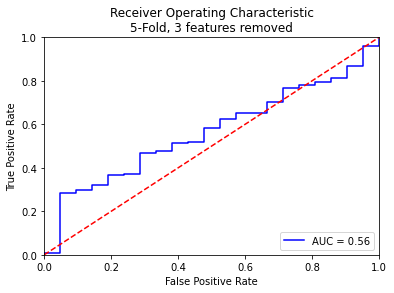

AUC: 0.5732


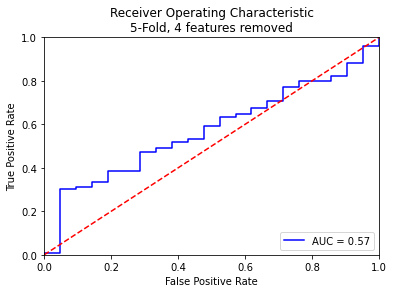

In [138]:
# Plot the ROC curve

%matplotlib inline


for i in range(5):
    
    X_train = kX_train[i]
    X_test  = kX_test[i]
    

    for j in range(4):
        # calculate the fpr and tpr for all thresholds of the classification
        if len(X_train) == len(y_train):
            pass
        else:
            X_train = X_train[:-1] #For some reason the kfold algorithm results in mismatching dimensions
        model = rfe(j+1).fit(X_train,y_train)
        probs = model.predict_proba(X_test)
        preds = probs[:,1]
        if len(y_test) == len(preds):
            pass
        else:
            y_test = y_test[:-1]
        fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
        roc_auc = metrics.auc(fpr, tpr)
        print("AUC: {}".format(round(roc_auc,4)))

        # Plot the ROC curve

        subtitle = str(i+1)+"-Fold, "+str(j+1)+" features removed"
        plt.title('Receiver Operating Characteristic\n'+subtitle)
        plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
        plt.legend(loc = 'lower right')
        plt.plot([0, 1], [0, 1],'r--')
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.show()

Question 4.2: Summarize your findings of all above models

#### These models don't seem to be as succesful in prediciting as the models and datasets in previous assignments. After tinkering with the number of features removed it seemed clear that of course the rate of true positive will increase while we remove features and this trend continues as the features are continually removed however, the AUC value itself seems to plateau after around 20 features are removed which suggests the marginal benefits found when removing features will vanish after a sufficient number of features are removed. 

## Question 5. Create a new text cell in your Notebook: Complete a 50-100 word summary (or short description of your thinking in applying this week's learning to the solution) of your experience in this assignment. Include:
                                                                      
* What was your incoming experience with this model, if any? 
* What steps you took, what obstacles you encountered.
* How you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?) 
> This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work.


#### I had no experience with the model going into this assignment unfortunately. I ran into trouble when trying to apply the RFE to the dataset intially but after increasing the interations, looking into the various solvers, and adjusting the tolerance I was able to get the model to converge. Using the saga solver with around 8000 iterations allowed me to generate the ROC plots but only after tinkering with it for a bit. I also had some intial issues in splitting the data in a training and testing set using the KFold approach but nothing major, I could see how splitting this way might be more useful in a context where we don't know how well the model works with a given dataset. I know I had issues initially when working with this dataset because the Logistic Regression algorithm with such a large number of interations ran so slowely that it made me wondering if it's even the most optimial or appropriate algorithm. I'm wondering if this sort of approach would be useful with the calorimeters found at the LHC because to my understanding they have thousands of sensors that have different functions, all of which work together to reconstruct a particles trajectory and energy for instance.